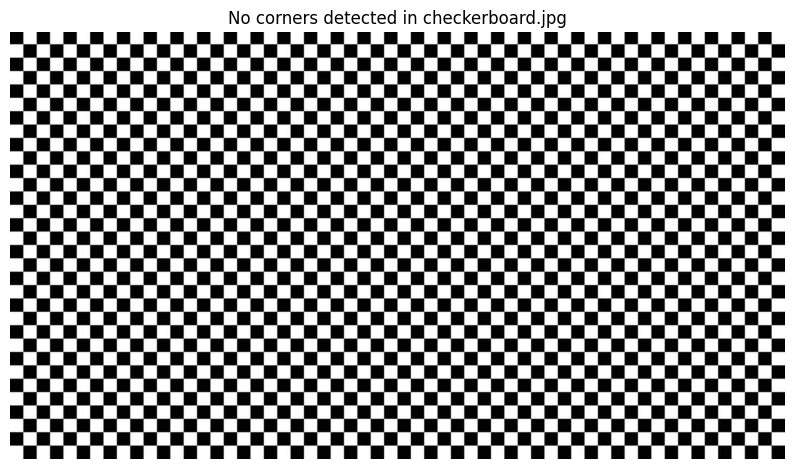

Error: No chessboard corners found in any of the provided images. Calibration cannot be performed.


In [6]:
import cv2, numpy as np, glob
from matplotlib import pyplot as plt

CHECKERBOARD = (6,9)
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1,2)

objpoints, imgpoints = [], []
images = glob.glob('checkerboard.jpg')

img_size = None

if not images:
    print("Error: No images found. Please ensure 'checkerboard.jpg' is in the same directory as this notebook.")
else:
    for f in images:
        img = cv2.imread(f)
        if img is None:
            print(f"Error: Could not read image {f}. Please check the file path and ensure it's a valid image.")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


        if img_size is None:
            img_size = gray.shape[::-1]

        ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)

        if ret:

            criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
            corners = cv2.cornerSubPix(gray, corners, (11,11), (-1,-1), criteria)

            objpoints.append(objp)
            imgpoints.append(corners)

            img_with_corners = cv2.drawChessboardCorners(img.copy(), CHECKERBOARD, corners, ret)
            plt.figure(figsize=(10, 7))
            plt.imshow(cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB))
            plt.title(f"Corners detected in {f}")
            plt.axis('off')
            plt.show()
            print(f"Chessboard corners successfully found in {f}")

        else:
            print(f"Warning: Chessboard corners not found in {f} with CHECKERBOARD={CHECKERBOARD}. Please check the image or the checkerboard size.")

            plt.figure(figsize=(10, 7))
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title(f"No corners detected in {f}")
            plt.axis('off')
            plt.show()

    if objpoints and imgpoints:
        ret_calib, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
            objpoints, imgpoints, img_size, None, None)

        print("Camera Matrix:\n", mtx)
        print("Distortion:\n", dist)
    else:
        print("Error: No chessboard corners found in any of the provided images. Calibration cannot be performed.")

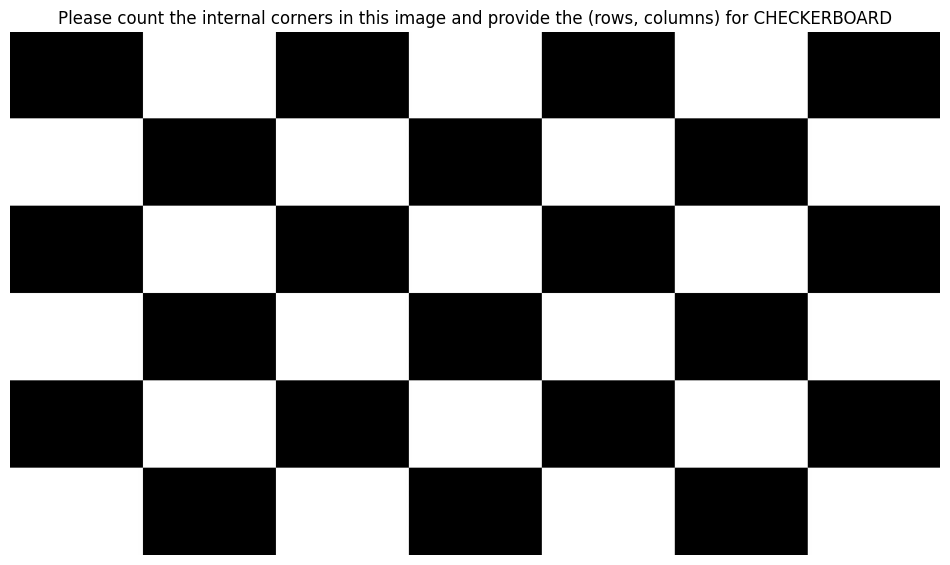

In [11]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread('checkerboard3.jpg')

if img is None:
    print("Error: Could not read 'checkerboard.jpg'. Please ensure the file exists.")
else:
    plt.figure(figsize=(12, 9))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Please count the internal corners in this image and provide the (rows, columns) for CHECKERBOARD")
    plt.axis('off')
    plt.show()

In [10]:
import cv2, numpy as np

objp = np.zeros((54,3), np.float32)
objp[:,:2] = np.mgrid[0:6,0:9].T.reshape(-1,2)

img = cv2.imread('checkerboard3.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, corners = cv2.findChessboardCorners(gray, (6,9))

if ret:
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        [objp], [corners], gray.shape[::-1], None, None)

    print("Camera Matrix:\n", mtx)
    print("Distortion:\n", dist)
